# Telecom Customer Churn Prediction
### IBM Telco Customer Churn Dataset — Classification Model

**Objective:** Predict which customers are likely to churn and surface the key drivers to enable targeted retention campaigns.

**Dataset:** 7,043 California telecom customers with 33 features covering demographics, service usage, contract terms, billing, churn scores, and customer lifetime value.

**Target:** `Churn Value` (0 = retained, 1 = churned)

**Stack:** Python, pandas, scikit-learn, imbalanced-learn, Matplotlib, Seaborn

In [55]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

PALETTE = {'No Churn': '#4C8BF5', 'Churn': '#E05C5C'}
os.makedirs('../visualizations', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


---
## 1. Data Loading & Inspection

In [56]:
df = pd.read_csv('../data/telecom_churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [58]:
print('Missing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nChurn distribution:')
print(df['Churn Label'].value_counts())
print('\nChurn rate:', df['Churn Label'].value_counts(normalize=True).round(4).to_dict())

Missing values:
Churn Reason    5174
dtype: int64

Churn distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: {'No': 0.7346, 'Yes': 0.2654}


In [59]:
df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Churn Score']].describe()

,Tenure Months,Monthly Charges,CLTV,Churn Score
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,4400.295755,58.699418
std,24.559481,30.090047,1183.057152,21.525131
min,0.000000,18.250000,2003.000000,5.000000
25%,9.000000,35.500000,3469.000000,40.000000
50%,29.000000,70.350000,4527.000000,61.000000
75%,55.000000,89.850000,5380.500000,75.000000
max,72.000000,118.750000,6500.000000,100.000000


---
## 2. Exploratory Data Analysis

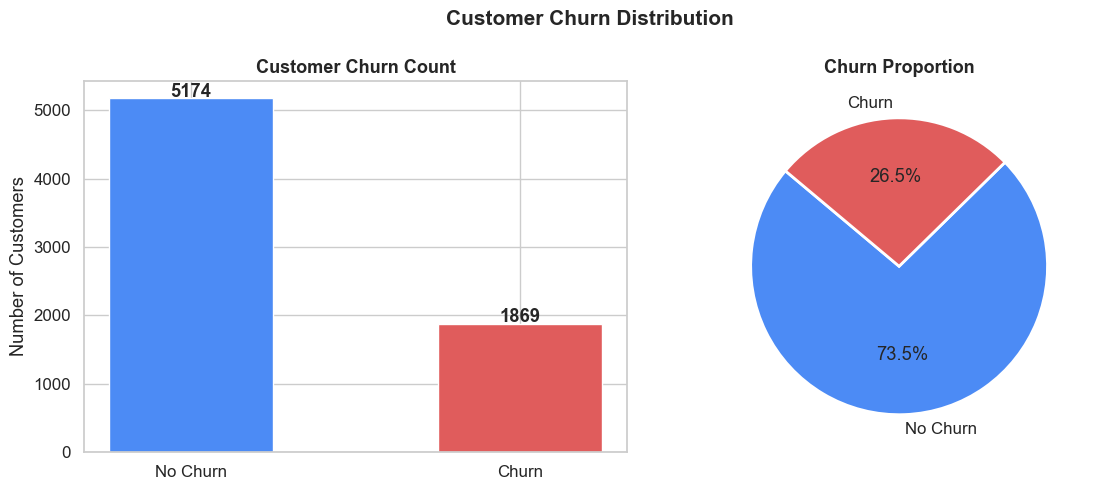

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Churn Label'].value_counts()
vals = [counts.get('No', 0), counts.get('Yes', 0)]
colors = [PALETTE['No Churn'], PALETTE['Churn']]

axes[0].bar(['No Churn', 'Churn'], vals, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Customer Churn Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(vals):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(vals, labels=['No Churn', 'Churn'], colors=colors, autopct='%1.1f%%',
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Customer Churn Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

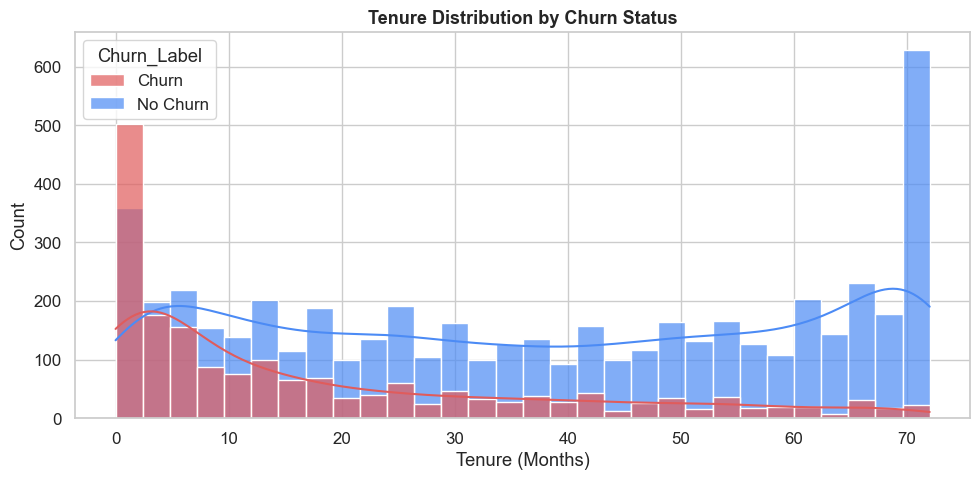

Mean tenure — No Churn: 37.6
Mean tenure — Churn:    18.0


In [61]:
fig, ax = plt.subplots(figsize=(10, 5))
df_plot = df.copy()
df_plot['Churn_Label'] = df_plot['Churn Label'].map({'Yes': 'Churn', 'No': 'No Churn'})

sns.histplot(data=df_plot, x='Tenure Months', hue='Churn_Label',
             palette=PALETTE, kde=True, ax=ax, bins=30, alpha=0.7)
ax.set_title('Tenure Distribution by Churn Status', fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure (Months)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../visualizations/02_tenure_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean tenure — No Churn:', df[df['Churn Label']=='No']['Tenure Months'].mean().round(1))
print('Mean tenure — Churn:   ', df[df['Churn Label']=='Yes']['Tenure Months'].mean().round(1))

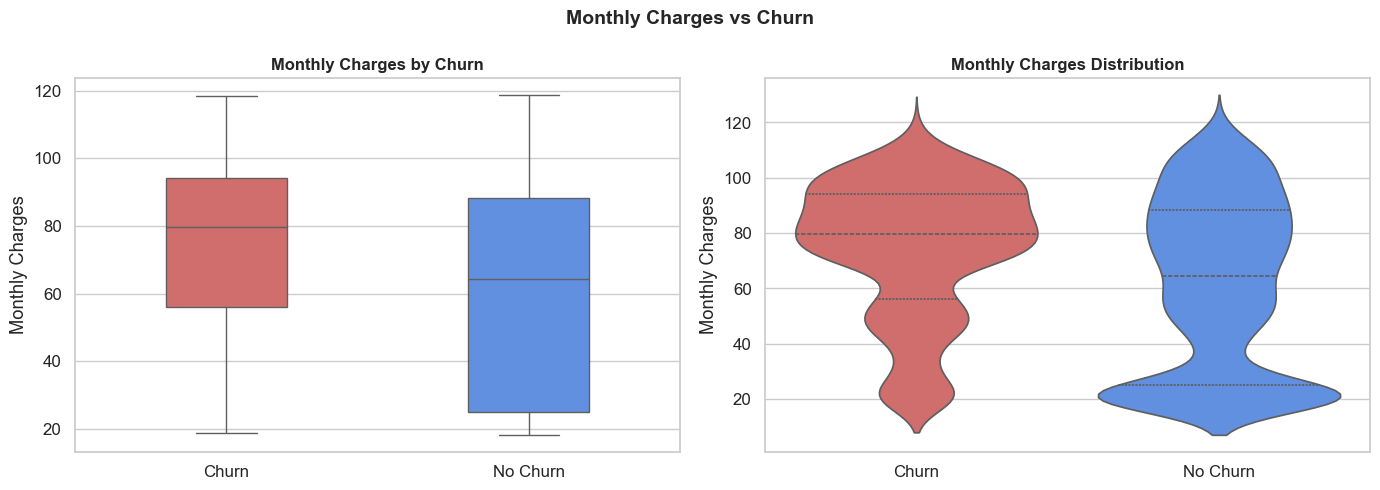

Mean monthly charge — No Churn: 61.27
Mean monthly charge — Churn:    74.44


In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_plot = df.copy()
df_plot['Churn_Label'] = df_plot['Churn Label'].map({'Yes': 'Churn', 'No': 'No Churn'})

sns.boxplot(data=df_plot, x='Churn_Label', y='Monthly Charges',
            palette=PALETTE, ax=axes[0], width=0.4)
axes[0].set_title('Monthly Charges by Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')

sns.violinplot(data=df_plot, x='Churn_Label', y='Monthly Charges',
               palette=PALETTE, ax=axes[1], inner='quartile')
axes[1].set_title('Monthly Charges Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')

plt.suptitle('Monthly Charges vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/03_monthly_charges_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean monthly charge — No Churn:', df[df['Churn Label']=='No']['Monthly Charges'].mean().round(2))
print('Mean monthly charge — Churn:   ', df[df['Churn Label']=='Yes']['Monthly Charges'].mean().round(2))

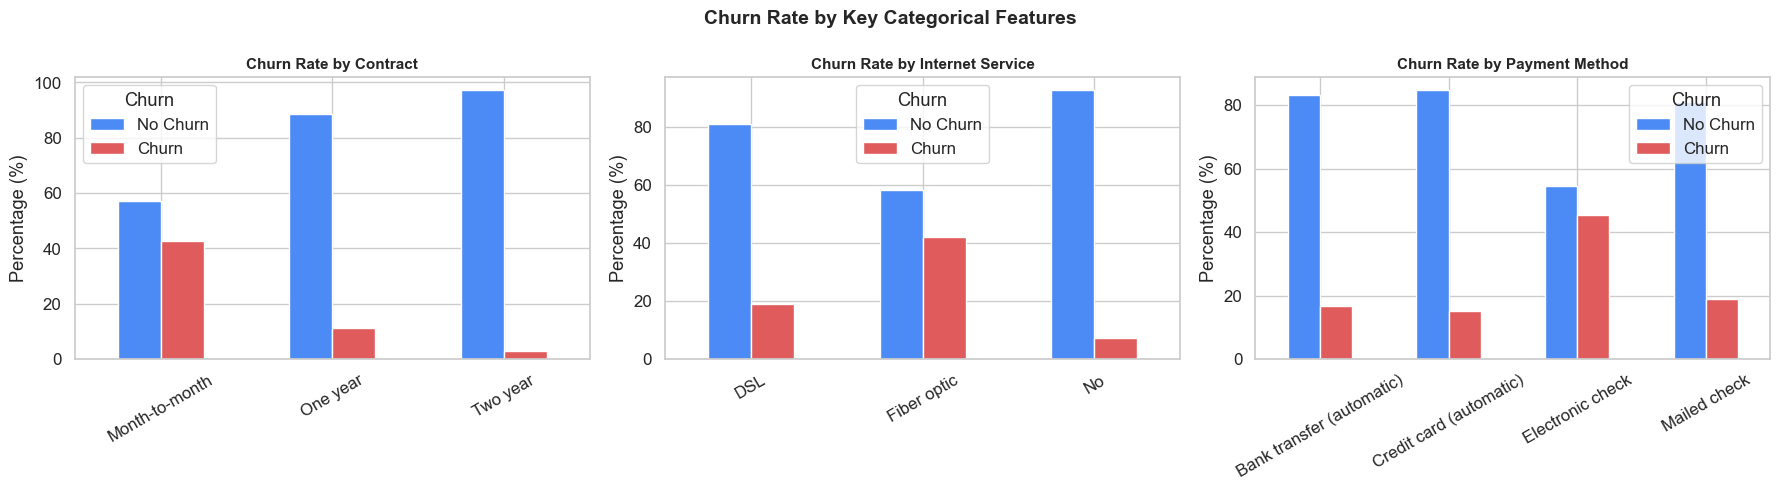

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['Contract', 'Internet Service', 'Payment Method']):
    ct = pd.crosstab(df[col], df['Churn Label'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=[PALETTE['No Churn'], PALETTE['Churn']],
            edgecolor='white', rot=30)
    ax.set_title(f'Churn Rate by {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xlabel('')
    ax.legend(title='Churn', labels=['No Churn', 'Churn'])

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/04_categorical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

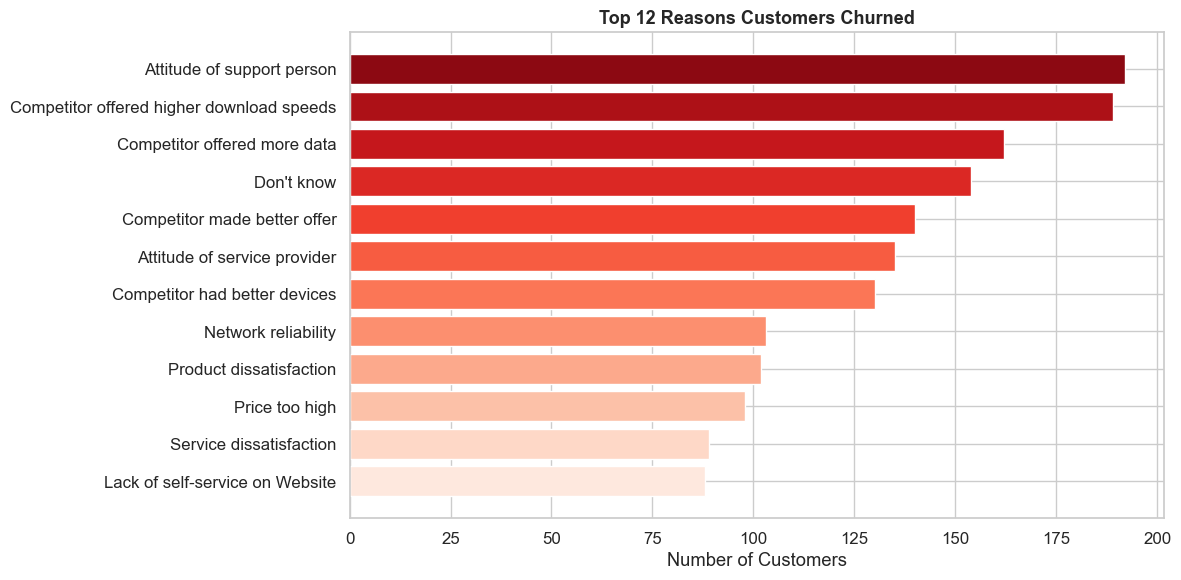

In [64]:
fig, ax = plt.subplots(figsize=(12, 6))
churn_reasons = df[df['Churn Label'] == 'Yes']['Churn Reason'].value_counts().head(12)
colors = sns.color_palette('Reds_r', len(churn_reasons))
ax.barh(churn_reasons.index[::-1], churn_reasons.values[::-1], color=colors[::-1], edgecolor='white')
ax.set_title('Top 12 Reasons Customers Churned', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers')
plt.tight_layout()
plt.savefig('../visualizations/05_churn_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

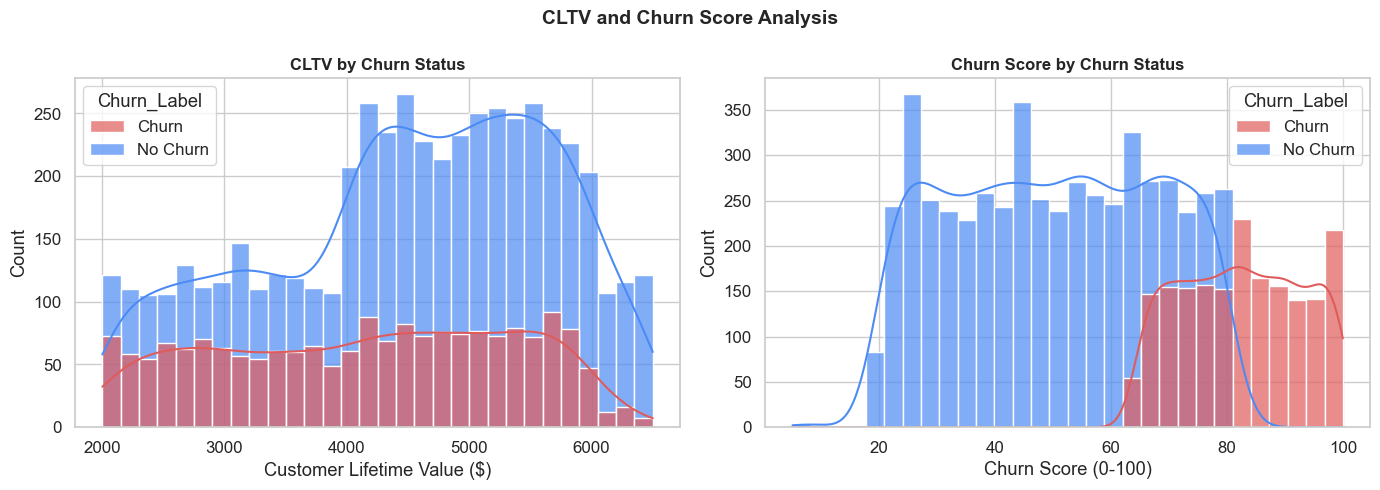

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_plot = df.copy()
df_plot['Churn_Label'] = df_plot['Churn Label'].map({'Yes': 'Churn', 'No': 'No Churn'})

sns.histplot(data=df_plot, x='CLTV', hue='Churn_Label', palette=PALETTE,
             kde=True, ax=axes[0], bins=30, alpha=0.7)
axes[0].set_title('CLTV by Churn Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Customer Lifetime Value ($)')

sns.histplot(data=df_plot, x='Churn Score', hue='Churn_Label', palette=PALETTE,
             kde=True, ax=axes[1], bins=30, alpha=0.7)
axes[1].set_title('Churn Score by Churn Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Churn Score (0-100)')

plt.suptitle('CLTV and Churn Score Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/06_cltv_and_score.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Data Preprocessing

In [66]:
df_clean = df.copy()

df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')
df_clean['Total Charges'].fillna(df_clean['Total Charges'].median(), inplace=True)

drop_cols = ['CustomerID', 'Count', 'Country', 'Lat Long', 'Churn Label', 'Churn Score', 'Churn Reason']
df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns], inplace=True)

df_clean.drop_duplicates(inplace=True)
df_clean.reset_index(drop=True, inplace=True)

print('Cleaned dataset shape:', df_clean.shape)
print('Target distribution (Churn Value):')
print(df_clean['Churn Value'].value_counts())
print('Churn rate:', df_clean['Churn Value'].mean().round(4))

Cleaned dataset shape: (7043, 26)
Target distribution (Churn Value):
Churn Value
0    5174
1    1869
Name: count, dtype: int64
Churn rate: 0.2654


---
## 4. Feature Engineering

In [67]:
service_cols = ['Online Security', 'Online Backup', 'Device Protection',
                'Tech Support', 'Streaming TV', 'Streaming Movies']

df_clean['num_services'] = df_clean[service_cols].apply(
    lambda row: sum(1 for v in row if v == 'Yes'), axis=1
)
df_clean['avg_monthly_spend'] = df_clean['Total Charges'] / (df_clean['Tenure Months'] + 1)
df_clean['charge_per_service'] = df_clean['Monthly Charges'] / (df_clean['num_services'] + 1)
df_clean['long_tenure'] = (df_clean['Tenure Months'] > 36).astype(int)
df_clean['high_cltv'] = (df_clean['CLTV'] > df_clean['CLTV'].median()).astype(int)

print('Engineered features added: num_services, avg_monthly_spend, charge_per_service, long_tenure, high_cltv')
df_clean[['num_services', 'avg_monthly_spend', 'charge_per_service', 'long_tenure', 'high_cltv']].describe()

Engineered features added: num_services, avg_monthly_spend, charge_per_service, long_tenure, high_cltv


,num_services,avg_monthly_spend,charge_per_service,long_tenure,high_cltv
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,2.037910,61.173413,25.490020,0.426097,0.499929
std,1.847682,61.019723,14.093315,0.494543,0.500035
min,0.000000,9.183333,8.650000,0.000000,0.000000
25%,0.000000,26.274411,18.025000,0.000000,0.000000
50%,2.000000,61.150000,20.660000,0.000000,0.000000
75%,3.000000,84.940047,27.425000,1.000000,1.000000
max,6.000000,1397.475000,77.900000,1.000000,1.000000


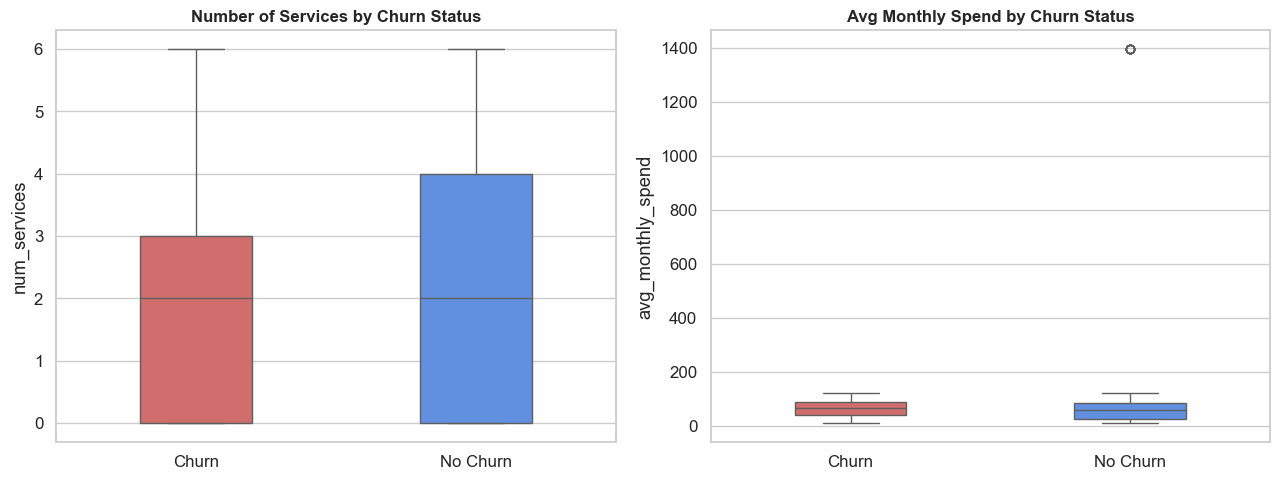

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df_plot2 = df_clean.copy()
df_plot2['Churn_Label'] = df_plot2['Churn Value'].map({1: 'Churn', 0: 'No Churn'})

sns.boxplot(data=df_plot2, x='Churn_Label', y='num_services',
            palette=PALETTE, ax=axes[0], width=0.4)
axes[0].set_title('Number of Services by Churn Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')

sns.boxplot(data=df_plot2, x='Churn_Label', y='avg_monthly_spend',
            palette=PALETTE, ax=axes[1], width=0.4)
axes[1].set_title('Avg Monthly Spend by Churn Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../visualizations/07_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Encoding & Scaling

In [69]:
df_encoded = df_clean.copy()

binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
for col in ['Gender', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']:
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(binary_map)

multi_cols = [
    'State', 'City',
    'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Payment Method'
]
df_encoded = pd.get_dummies(df_encoded, columns=[c for c in multi_cols if c in df_encoded.columns], drop_first=False)

print('Encoded shape:', df_encoded.shape)
df_encoded.head(3)

Encoded shape: (7043, 1180)


,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,...,Streaming Movies_No,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,90003,33.964131,-118.272783,1,No,0,0,2,1,1,...,True,False,False,True,False,False,False,False,False,True
1,90005,34.059281,-118.307420,0,No,0,1,2,1,1,...,True,False,False,True,False,False,False,False,True,False
2,90006,34.048013,-118.293953,0,No,0,1,8,1,1,...,False,False,True,True,False,False,False,False,True,False


In [70]:
X = df_encoded.drop(columns=['Churn Value'])
y = df_encoded['Churn Value'].astype(int)

numeric_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges',
                'CLTV', 'Zip Code', 'Latitude', 'Longitude',
                'num_services', 'avg_monthly_spend', 'charge_per_service']
existing_numeric = [c for c in numeric_cols if c in X.columns]

scaler = StandardScaler()
X[existing_numeric] = scaler.fit_transform(X[existing_numeric])

print('Feature matrix shape:', X.shape)
print('Target counts:')
print(y.value_counts())

Feature matrix shape: (7043, 1179)
Target counts:
Churn Value
0    5174
1    1869
Name: count, dtype: int64


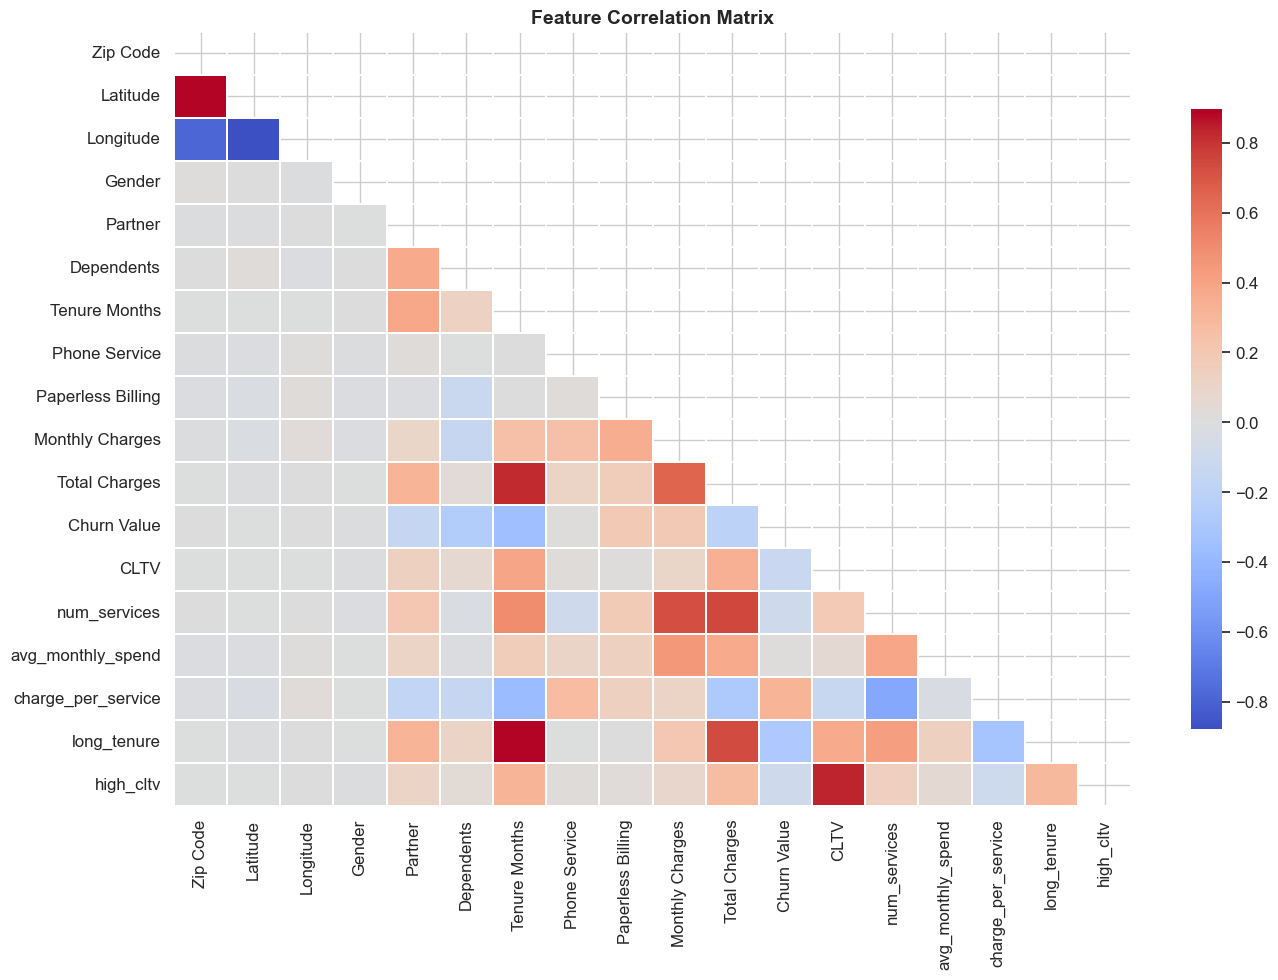

In [71]:
fig, ax = plt.subplots(figsize=(14, 10))
numeric_df = df_encoded.select_dtypes(include=np.number)
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            ax=ax, linewidths=0.3, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/08_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Train/Test Split & SMOTE Balancing

In [ ]:
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

print(f'Original training set: {X_train.shape[0]} samples')
print(f'After SMOTE: {X_res.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'Test churn rate: {y_test.mean():.2%}')

Original training set: 5634 samples
After SMOTE: 8278 samples
Test set: 1409 samples
Test churn rate: 26.54%


---
## 7. Model Training

In [73]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', C=0.5)
lr_model.fit(X_res, y_res)
print('Logistic Regression trained.')

Logistic Regression trained.


In [74]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=4,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_res, y_res)
print('Random Forest trained.')

Random Forest trained.


In [75]:
gb_model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=42
)
gb_model.fit(X_res, y_res)
print('Gradient Boosting trained.')

Gradient Boosting trained.


---
## 8. Model Evaluation

In [76]:
def evaluate(model, name, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    print(f'\n=== {name} ===')
    print(f'  Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
    print(f'  Precision: {precision_score(y_test, y_pred):.4f}')
    print(f'  Recall:    {recall_score(y_test, y_pred):.4f}')
    print(f'  F1 Score:  {f1_score(y_test, y_pred):.4f}')
    print(f'  ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}')
    print('\nConfusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
    return y_prob

lr_prob = evaluate(lr_model, 'Logistic Regression', X_test, y_test)
rf_prob = evaluate(rf_model, 'Random Forest', X_test, y_test)
gb_prob = evaluate(gb_model, 'Gradient Boosting', X_test, y_test)


=== Logistic Regression ===
  Accuracy:  0.7913
  Precision: 0.6005
  Recall:    0.6390
  F1 Score:  0.6192
  ROC AUC:   0.8444

Confusion Matrix:
[[876 159]
 [135 239]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.85      0.86      1035
       Churn       0.60      0.64      0.62       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.74      1409
weighted avg       0.80      0.79      0.79      1409


=== Random Forest ===
  Accuracy:  0.7637
  Precision: 0.5390
  Recall:    0.7567
  F1 Score:  0.6296
  ROC AUC:   0.8384

Confusion Matrix:
[[793 242]
 [ 91 283]]

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.77      0.83      1035
       Churn       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg     

In [77]:
models_dict = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

rows = []
for name, model in models_dict.items():
    y_prob_ = model.predict_proba(X_test)[:, 1]
    y_pred_ = (y_prob_ >= 0.5).astype(int)
    rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred_), 4),
        'Precision': round(precision_score(y_test, y_pred_), 4),
        'Recall': round(recall_score(y_test, y_pred_), 4),
        'F1 Score': round(f1_score(y_test, y_pred_), 4),
        'ROC AUC': round(roc_auc_score(y_test, y_prob_), 4)
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.7913,0.6005,0.6390,0.6192,0.8444
Random Forest,0.7637,0.5390,0.7567,0.6296,0.8384
Gradient Boosting,0.7814,0.5721,0.7005,0.6298,0.8499


---
## 9. Model Performance Visualizations

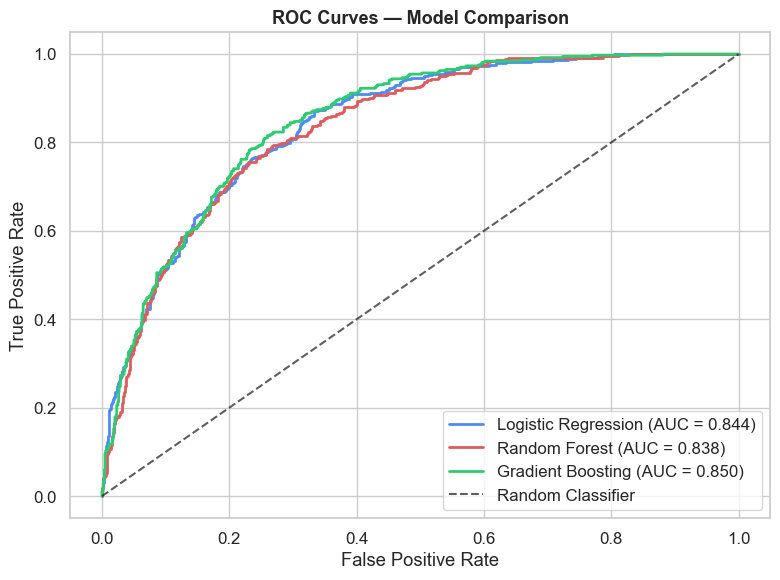

In [78]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#4C8BF5', '#E05C5C', '#2ECC71']

for (name, model), color in zip(models_dict.items(), colors):
    y_prob_ = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob_)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.7, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../visualizations/09_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

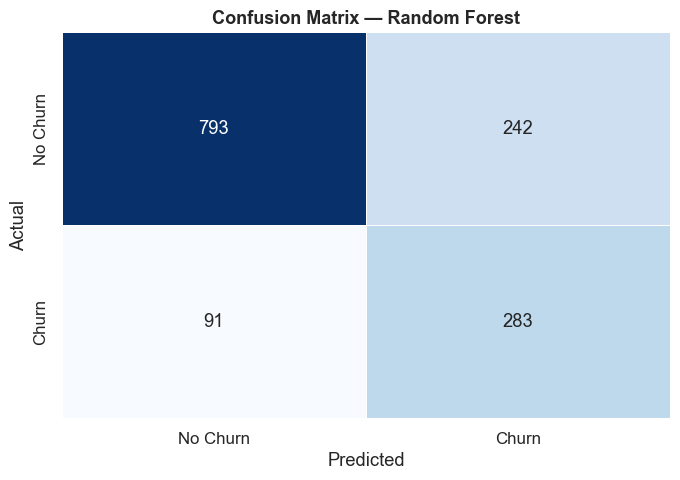

In [79]:
y_pred_rf = (rf_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=0.5, cbar=False)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../visualizations/10_confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

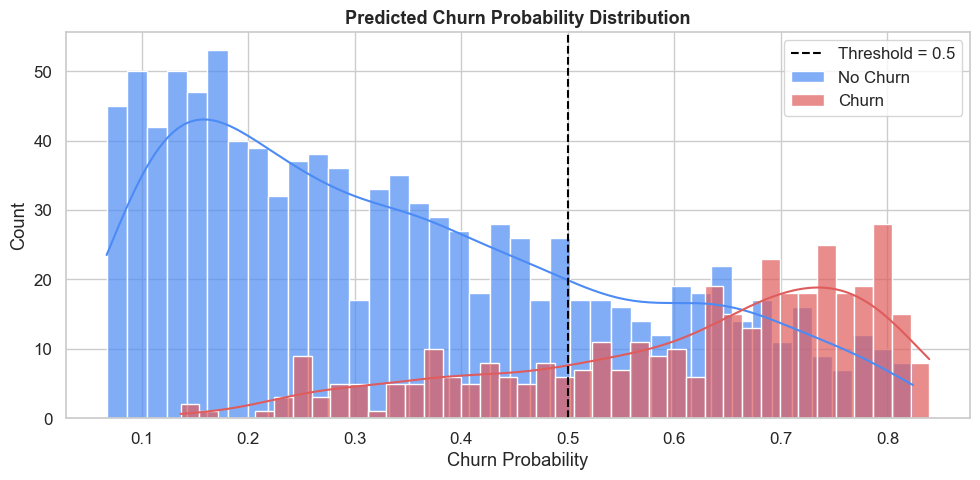

In [80]:
fig, ax = plt.subplots(figsize=(10, 5))
df_prob = pd.DataFrame({'prob': rf_prob, 'actual': y_test.values})

sns.histplot(data=df_prob[df_prob['actual'] == 0], x='prob', bins=40,
             color=PALETTE['No Churn'], label='No Churn', alpha=0.7, ax=ax, kde=True)
sns.histplot(data=df_prob[df_prob['actual'] == 1], x='prob', bins=40,
             color=PALETTE['Churn'], label='Churn', alpha=0.7, ax=ax, kde=True)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold = 0.5')
ax.set_title('Predicted Churn Probability Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Churn Probability')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/11_probability_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Feature Importance

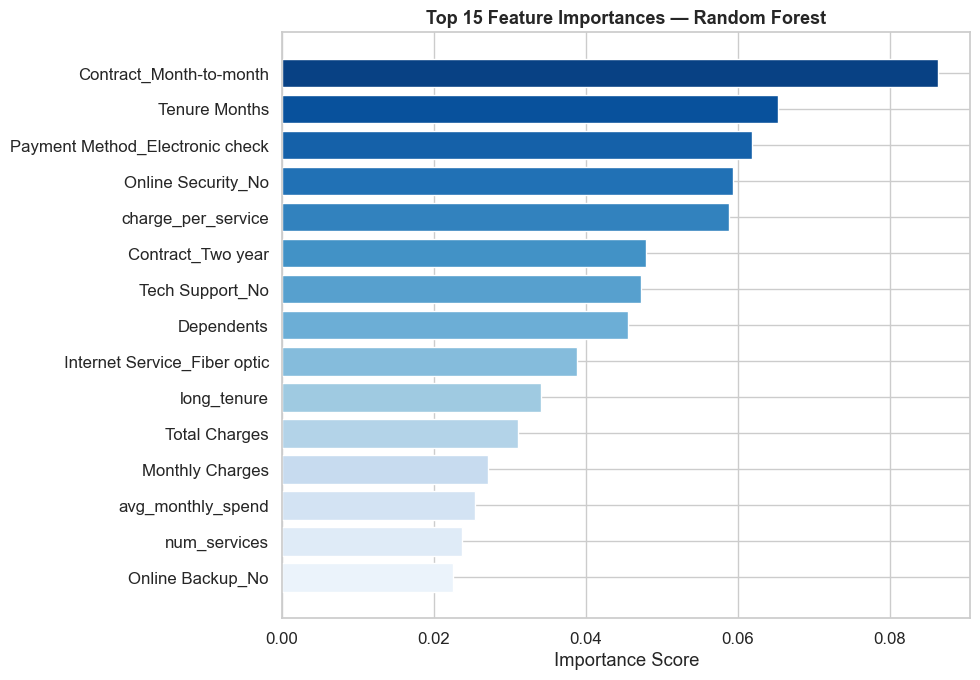

,feature,importance
1171,Contract_Month-to-month,0.086301
6,Tenure Months,0.065292
1176,Payment Method_Electronic check,0.061905
1153,Online Security_No,0.059411
14,charge_per_service,0.058827
1173,Contract_Two year,0.047963
1162,Tech Support_No,0.047239
5,Dependents,0.045511
1151,Internet Service_Fiber optic,0.038824
15,long_tenure,0.034078


In [81]:
fi_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors_ = sns.color_palette('Blues_r', len(fi_df))
ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
        color=colors_[::-1], edgecolor='white')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../visualizations/12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

fi_df

---
## 11. Customer Risk Scoring Output

In [82]:
churn_probs = gb_model.predict_proba(X_test)[:, 1]

output_df = X_test.copy()
output_df['actual_churn'] = y_test.values
output_df['churn_probability'] = churn_probs.round(4)
output_df['predicted_churn'] = (churn_probs >= 0.5).astype(int)
output_df['risk_tier'] = pd.cut(
    output_df['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print('Risk tier distribution:')
print(output_df['risk_tier'].value_counts())

print('\nTop 10 highest churn probability customers:')
output_df[['churn_probability', 'predicted_churn', 'actual_churn', 'risk_tier']].sort_values(
    'churn_probability', ascending=False
).head(10)

Risk tier distribution:
risk_tier
Low Risk       776
High Risk      363
Medium Risk    270
Name: count, dtype: int64

Top 10 highest churn probability customers:


,churn_probability,predicted_churn,actual_churn,risk_tier
1203,0.9342,1,1,High Risk
598,0.9319,1,1,High Risk
719,0.9220,1,1,High Risk
753,0.9152,1,1,High Risk
3364,0.9145,1,0,High Risk
2567,0.9139,1,0,High Risk
731,0.9136,1,1,High Risk
758,0.9134,1,1,High Risk
236,0.9128,1,1,High Risk
964,0.9128,1,1,High Risk


In [83]:
output_df.to_csv('../data/churn_predictions.csv', index=False)
joblib.dump(lr_model, '../models/logistic_regression.pkl')
joblib.dump(rf_model, '../models/random_forest.pkl')
joblib.dump(gb_model, '../models/gradient_boosting.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print('Predictions saved to ../data/churn_predictions.csv')
print('All models saved to ../models/')

Predictions saved to ../data/churn_predictions.csv
All models saved to ../models/
